Prompt ->

Create a Jupyter Notebook in Python where I can analyze city-level COVID-19 data and present it in a simple dashboard style. Start by loading the dataset using pandas, clean it by handling missing values, and convert the date column properly. Then do some basic analysis like grouping data by city and calculating daily cases or simple trends.
After that, add some clear and neat graphs using seaborn or matplotlib like a box plot for cases, a violin plot for daily cases, a heatmap for confirmed, deaths, and recovered, and a line chart to show how cases change over time for different cities. Keep the graphs simple, readable, and not too crowded.
Then include some interactive charts using plotly such as a line chart where I can select cities, a pie chart showing active, recovered, and death cases, and a bar chart for top affected cities. Also create a simple map using folium where cities are marked with circles based on number of cases and show basic information in popups.
Organize the notebook properly with sections like introduction, data loading, cleaning, analysis, visualizations, map, and conclusion. Keep the code easy to understand with small comments and make the overall notebook look clean and presentable like a normal student project.

<div style="background: linear-gradient(to right, #4facfe, #00f2fe); 
            padding: 20px; 
            border-radius: 12px; 
            color: white; 
            text-align: center;
            box-shadow: 0px 4px 10px rgba(0,0,0,0.2);">

<h1 style="margin-bottom: 10px;">COVID-19 City Dashboard</h1>
    <h3 style="margin: 5px 0;">Name: Prince</h3>
    <h3 style="margin: 5px 0;">Roll No: 2401301022</h3>
    <h3 style="margin: 5px 0;">Course: B.Tech CSE</h3>
    <h3 style="margin: 5px 0;">Section: A</h3>
    
<hr style="border: 1px solid white; width: 60%; margin: 15px auto;">
    
<h4 style="margin-top: 10px;">Submitted To</h4>
    <h3 style="margin: 5px 0;">Mr. Maninder Singh Sir</h3>

</div>

<div style="background:linear-gradient(135deg,#0f0c29,#302b63,#24243e);padding:50px 40px;border-radius:20px;text-align:center;box-shadow:0 8px 32px rgba(0,0,0,0.6);border:1px solid rgba(255,255,255,0.08);">
  <div style="font-size:3.2em;margin-bottom:10px;">🦠</div>
  <h1 style="color:#fff;font-size:2.6em;margin:0;letter-spacing:3px;text-shadow:0 0 30px #e94560aa;">COVID-19 City Dashboard</h1>
  <p style="color:#a8dadc;font-size:1.15em;margin-top:12px;letter-spacing:1px;">Advanced Interactive Analytics · India · 2021</p>
  <div style="display:flex;justify-content:center;gap:30px;margin-top:24px;flex-wrap:wrap;">
    <span style="background:rgba(233,69,96,0.2);color:#e94560;padding:6px 18px;border-radius:20px;border:1px solid #e94560;font-size:.9em;">🏙️ 10 Cities</span>
    <span style="background:rgba(168,218,220,0.2);color:#a8dadc;padding:6px 18px;border-radius:20px;border:1px solid #a8dadc;font-size:.9em;">📅 May–Aug 2021</span>
    <span style="background:rgba(244,162,97,0.2);color:#f4a261;padding:6px 18px;border-radius:20px;border:1px solid #f4a261;font-size:.9em;">📊 1,200 Records</span>
    <span style="background:rgba(42,157,143,0.2);color:#2a9d8f;padding:6px 18px;border-radius:20px;border:1px solid #2a9d8f;font-size:.9em;">🧬 10 Features</span>
  </div>
</div>

<div style="background:#161b22;border:1px solid #30363d;border-radius:12px;padding:25px 30px;margin:10px 0;">
<h3 style="color:#f0f6fc;margin-top:0;">📋 Table of Contents</h3>

| # | Section | Description |
|---|---------|-------------|
| 1 | [⚙️ Setup & Imports](#setup) | Libraries, themes, global config |
| 2 | [📂 Data Loading](#loading) | Load real CSV dataset |
| 3 | [🔧 Preprocessing](#preprocessing) | Clean, engineer features |
| 4 | [🔍 EDA](#eda) | Statistics & summary tables |
| 5 | [📊 Static Charts](#static) | Box · Violin · Heatmap · Trends |
| 6 | [📈 Interactive Charts](#interactive) | Plotly line · pie · bar · animation |
| 7 | [🗺️ Geographic Map](#map) | Folium city map |
| 8 | [🎛️ Widgets](#widgets) | ipywidgets live filter |
| 9 | [💡 Insights](#insights) | Key findings & conclusion |
</div>

---
## <a id="setup"></a>⚙️ 1 · Setup & Imports
> Run `pip install plotly folium ipywidgets` once if any are missing.

In [25]:
# ─── Core ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ─── Static Visualizations ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
import seaborn as sns

# ─── Interactive Visualizations ─────────────────────────────────────────────
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ─── Geographic Map ──────────────────────────────────────────────────────────
import folium
from folium.plugins import MarkerCluster, HeatMap, MiniMap

# ─── Widgets ─────────────────────────────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display, HTML, IFrame

# ═══════════════════ GLOBAL DARK THEME ═══════════════════════════════════════
BG       = '#0d1117'   # page background
SURFACE  = '#161b22'   # card / axes background
BORDER   = '#30363d'   # subtle border
TEXT     = '#c9d1d9'   # body text
HEADING  = '#f0f6fc'   # headings
RED      = '#e94560'   # primary accent (danger / confirmed)
CYAN     = '#a8dadc'   # secondary accent
ORANGE   = '#f4a261'   # tertiary
TEAL     = '#2a9d8f'   # quaternary
GOLD     = '#e9c46a'
PURPLE   = '#7c3aed'

PALETTE6 = [RED, CYAN, ORANGE, TEAL, GOLD, PURPLE]

plt.rcParams.update({
    'figure.dpi':        130,
    'figure.facecolor':  BG,
    'axes.facecolor':    SURFACE,
    'axes.edgecolor':    BORDER,
    'axes.labelcolor':   TEXT,
    'axes.titlecolor':   HEADING,
    'axes.titlesize':    14,
    'axes.labelsize':    11,
    'xtick.color':       '#8b949e',
    'ytick.color':       '#8b949e',
    'grid.color':        '#21262d',
    'grid.linestyle':    '--',
    'grid.alpha':        0.6,
    'text.color':        TEXT,
    'legend.facecolor':  SURFACE,
    'legend.edgecolor':  BORDER,
    'legend.fontsize':   9,
    'font.family':       'DejaVu Sans',
})

def styled_title(ax, title, subtitle=None):
    """Render a two-line title with accent underline."""
    ax.set_title(title, fontsize=15, fontweight='bold', color=HEADING, pad=14)
    if subtitle:
        ax.annotate(subtitle, xy=(0.5, 1.02), xycoords='axes fraction',
                    ha='center', fontsize=9, color='#8b949e')

print('✅  Libraries loaded  |  Dark theme configured')


✅  Libraries loaded  |  Dark theme configured


---
## <a id="loading"></a>📂 2 · Data Loading

In [26]:
# ── Load the real CSV ────────────────────────────────────────────────────────
DATA_PATH = 'covid_city_advanced_dataset.csv'   # adjust path if needed

df_raw = pd.read_csv(DATA_PATH)

# Quick peek
display(HTML(f"""
<div style='background:{SURFACE};border:1px solid {BORDER};border-radius:10px;
            padding:18px;color:{TEXT};font-family:monospace;'>
  <span style='color:{CYAN};font-size:1.1em;'>📂 {DATA_PATH}</span><br><br>
  <b>Rows:</b> {df_raw.shape[0]:,} &nbsp;|&nbsp;
  <b>Columns:</b> {df_raw.shape[1]} &nbsp;|&nbsp;
  <b>Cities:</b> {df_raw['City'].nunique()} &nbsp;|&nbsp;
  <b>Date range:</b> {df_raw['Date'].min()} → {df_raw['Date'].max()}
</div>
"""))

df_raw.head(8).style \
    .background_gradient(subset=['Confirmed','Deaths','Recovered'], cmap='Reds') \
    .format({'Confirmed':'{:,}','Deaths':'{:,}','Recovered':'{:,}',
             'Tests':'{:,}','Vaccinated':'{:,}','Positivity_Rate':'{:.1f}%'}) \
    .set_properties(**{'background-color': SURFACE, 'color': TEXT,
                       'border-color': BORDER})


,Date,City,Confirmed,Recovered,Deaths,Tests,Vaccinated,Positivity_Rate,Latitude,Longitude
0,2021-05-01,Delhi,"12,130","9,047",310,"36,390","6,734",33.3%,28.704100,77.102500
1,2021-05-02,Delhi,"13,439","9,931",150,"40,317","9,322",33.3%,28.704100,77.102500
2,2021-05-03,Delhi,"12,955","9,251",316,"51,820","7,949",25.0%,28.704100,77.102500
3,2021-05-04,Delhi,"13,703","10,214",187,"54,812","7,396",25.0%,28.704100,77.102500
4,2021-05-05,Delhi,"12,017","8,481",246,"60,085","8,849",20.0%,28.704100,77.102500
5,2021-05-06,Delhi,"13,317","10,294",230,"53,268","3,734",25.0%,28.704100,77.102500
6,2021-05-07,Delhi,"11,832","9,413",350,"35,496","4,556",33.3%,28.704100,77.102500
7,2021-05-08,Delhi,"11,916","8,849",134,"35,748","9,433",33.3%,28.704100,77.102500


---
## <a id="preprocessing"></a>🔧 3 · Data Cleaning & Feature Engineering

In [27]:
df = df_raw.copy()

# ── 3.1  Standardise column names ────────────────────────────────────────────
df.columns = [c.strip() for c in df.columns]

# ── 3.2  Parse dates ─────────────────────────────────────────────────────────
df['Date'] = pd.to_datetime(df['Date'])

# ── 3.3  Sort for diff calculations ──────────────────────────────────────────
df = df.sort_values(['City', 'Date']).reset_index(drop=True)

# ── 3.4  Ensure numeric & clip negatives ─────────────────────────────────────
num_cols = ['Confirmed','Recovered','Deaths','Tests','Vaccinated','Positivity_Rate']
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')
df[num_cols] = df[num_cols].fillna(method='ffill').fillna(0).clip(lower=0)

# ── 3.5  Feature engineering ─────────────────────────────────────────────────
grp = df.groupby('City')

df['Daily_New']        = grp['Confirmed'].diff().fillna(0).clip(lower=0)
df['Daily_Deaths']     = grp['Deaths'].diff().fillna(0).clip(lower=0)
df['Daily_Recovered']  = grp['Recovered'].diff().fillna(0).clip(lower=0)
df['Daily_Tests']      = grp['Tests'].diff().fillna(0).clip(lower=0)
df['Daily_Vaccinated'] = grp['Vaccinated'].diff().fillna(0).clip(lower=0)
df['Active']           = (df['Confirmed'] - df['Deaths'] - df['Recovered']).clip(lower=0)
df['Fatality_Rate']    = (df['Deaths'] / df['Confirmed'].replace(0, np.nan) * 100).round(2)
df['Recovery_Rate']    = (df['Recovered'] / df['Confirmed'].replace(0, np.nan) * 100).round(2)
df['Vax_Coverage']     = (df['Vaccinated'] / df['Tests'].replace(0, np.nan) * 100).round(2)
df['Rolling7']         = grp['Daily_New'].transform(lambda x: x.rolling(7, min_periods=1).mean())
df['Growth_Rate']      = grp['Confirmed'].pct_change(7).mul(100).round(2).fillna(0)

df['Week']  = df['Date'].dt.isocalendar().week.astype(int)
df['Month'] = df['Date'].dt.to_period('M').astype(str)

# ── 3.6  Latest snapshot per city ────────────────────────────────────────────
latest = df.groupby('City').last().reset_index()

print('✅  Preprocessing done!')
print(f'   Rows        : {df.shape[0]:,}')
print(f'   Features    : {df.shape[1]}')
print(f'   Date range  : {df.Date.min().date()} → {df.Date.max().date()}')
print(f'   Cities      : {sorted(df.City.unique().tolist())}')


✅  Preprocessing done!
   Rows        : 1,200
   Features    : 23
   Date range  : 2021-05-01 → 2021-08-28
   Cities      : ['Bangalore', 'Chennai', 'Delhi', 'Gurugram', 'Hyderabad', 'Kolkata', 'Mumbai', 'Noida', 'Panipat', 'Pune']


---
## <a id="eda"></a>🔍 4 · Exploratory Data Analysis

In [28]:
# ── 4.1  KPI Banner ──────────────────────────────────────────────────────────
total_conf  = int(latest['Confirmed'].sum())
total_death = int(latest['Deaths'].sum())
total_rec   = int(latest['Recovered'].sum())
total_vax   = int(latest['Vaccinated'].sum())
avg_pos     = float(df['Positivity_Rate'].mean())
avg_fat     = float(latest['Fatality_Rate'].mean())

kpis = [
    ('🦠 Total Confirmed', f'{total_conf:,}',  RED),
    ('💉 Total Vaccinated',f'{total_vax:,}',   TEAL),
    ('💚 Total Recovered', f'{total_rec:,}',   '#2a9d8f'),
    ('💀 Total Deaths',    f'{total_death:,}', ORANGE),
    ('🧪 Avg Positivity',  f'{avg_pos:.1f}%',  GOLD),
    ('📉 Avg Fatality',    f'{avg_fat:.2f}%',  PURPLE),
]

cards = ''.join(f"""
<div style='background:{SURFACE};border:1px solid {c};border-radius:12px;
            padding:18px 24px;text-align:center;min-width:160px;flex:1;'>
  <div style='color:{c};font-size:1.5em;font-weight:700;'>{v}</div>
  <div style='color:#8b949e;font-size:.82em;margin-top:6px;'>{label}</div>
</div>""" for label, v, c in kpis)

display(HTML(f"""
<div style='display:flex;gap:14px;flex-wrap:wrap;margin:10px 0;'>{cards}</div>
"""))

# ── 4.2  Per-city summary table ───────────────────────────────────────────────
display(HTML(f'<h4 style="color:{CYAN}">🏙️  City-Level Summary</h4>'))
summary = latest[['City','Confirmed','Deaths','Recovered','Active','Vaccinated',
                   'Fatality_Rate','Recovery_Rate','Positivity_Rate']] \
            .sort_values('Confirmed', ascending=False)

summary.style \
    .background_gradient(subset=['Confirmed'], cmap='Reds') \
    .background_gradient(subset=['Recovery_Rate'], cmap='Greens') \
    .background_gradient(subset=['Fatality_Rate'], cmap='Oranges') \
    .format({'Confirmed':'{:,}','Deaths':'{:,}','Recovered':'{:,}',
             'Active':'{:,}','Vaccinated':'{:,}',
             'Fatality_Rate':'{:.2f}%','Recovery_Rate':'{:.1f}%',
             'Positivity_Rate':'{:.1f}%'}) \
    .set_properties(**{'background-color': SURFACE, 'color': TEXT})


,City,Confirmed,Deaths,Recovered,Active,Vaccinated,Fatality_Rate,Recovery_Rate,Positivity_Rate
1,Chennai,"18,228",535,"16,398","1,295","3,591",2.94%,90.0%,20.0%
8,Panipat,"17,783",288,"13,733","3,762","5,841",1.62%,77.2%,20.0%
6,Mumbai,"17,725",361,"15,677","1,687","9,502",2.04%,88.5%,33.3%
5,Kolkata,"15,410",370,"14,449",591,"6,832",2.40%,93.8%,25.0%
4,Hyderabad,"15,203",208,"12,685","2,310","4,768",1.37%,83.4%,25.0%
7,Noida,"14,391",232,"12,506","1,653","8,382",1.61%,86.9%,25.0%
9,Pune,"13,587",281,"10,981","2,325","7,238",2.07%,80.8%,25.0%
0,Bangalore,"13,370",397,"11,019","1,954","5,358",2.97%,82.4%,20.0%
2,Delhi,"12,903",163,"9,150","3,590","9,175",1.26%,70.9%,33.3%
3,Gurugram,"8,857",263,"7,578","1,016","6,869",2.97%,85.6%,25.0%


---
## <a id="static"></a>📊 5 · Static Visualizations — Seaborn & Matplotlib

### 📦 5A · Box Plot — Daily New Cases Distribution by City

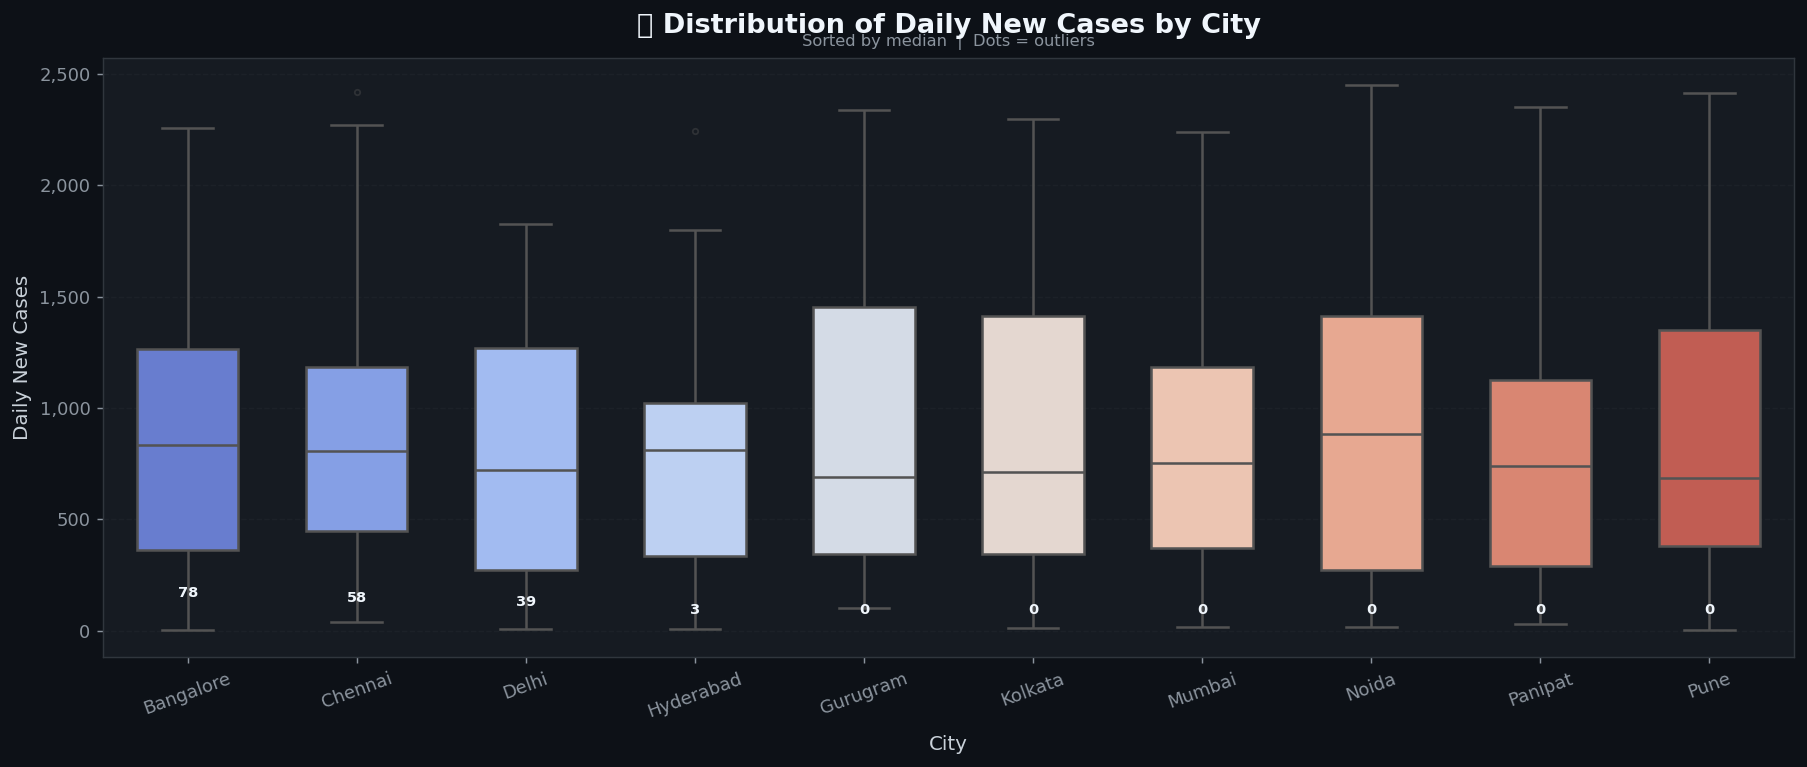

💡 Insight: Delhi & Mumbai show the widest spread, indicating high day-to-day variability during wave surges.


In [29]:
order = (df.groupby('City')['Daily_New'].median()
           .sort_values(ascending=False).index.tolist())
pal   = sns.color_palette('coolwarm', n_colors=len(order))

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df[df['Daily_New']>0], x='City', y='Daily_New',
            order=order, palette=pal, linewidth=1.4, width=0.6,
            flierprops=dict(marker='o', color=RED, markersize=3, alpha=0.4),
            ax=ax)

# Annotate medians
for i, city in enumerate(order):
    med = df[df['City']==city]['Daily_New'].median()
    ax.text(i, med + 60, f'{med:.0f}', ha='center', va='bottom',
            fontsize=8, color=HEADING, fontweight='bold')

styled_title(ax, '📦 Distribution of Daily New Cases by City',
             'Sorted by median  |  Dots = outliers')
ax.set_xlabel('City', labelpad=8)
ax.set_ylabel('Daily New Cases')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y')
plt.tight_layout()
plt.savefig('chart_box.png', dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()
print('💡 Insight: Delhi & Mumbai show the widest spread, indicating high day-to-day variability during wave surges.')


### 🎻 5B · Violin Plot — Spread of Daily New Cases

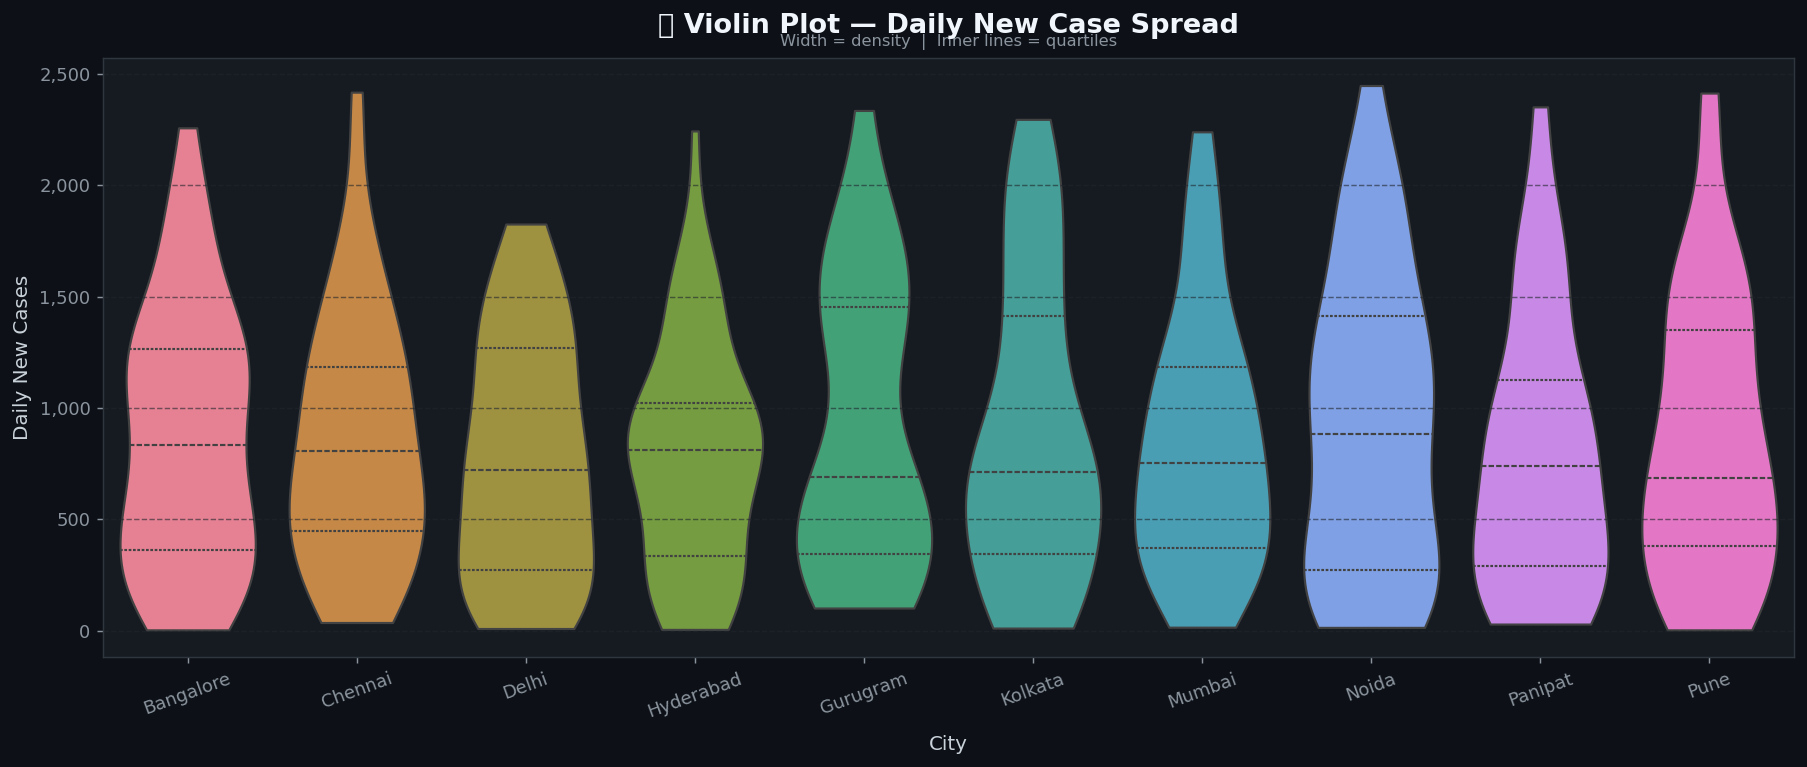

💡 Insight: Bimodal shapes in some cities (two bulges) indicate two distinct surge periods within the data window.


In [30]:
fig, ax = plt.subplots(figsize=(14, 6))
pal2 = sns.color_palette('husl', n_colors=len(order))
sns.violinplot(data=df[df['Daily_New']>0], x='City', y='Daily_New',
               order=order, palette=pal2,
               inner='quartile', linewidth=1.2, cut=0, ax=ax)
styled_title(ax, '🎻 Violin Plot — Daily New Case Spread',
             'Width = density  |  Inner lines = quartiles')
ax.set_xlabel('City', labelpad=8)
ax.set_ylabel('Daily New Cases')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y')
plt.tight_layout()
plt.savefig('chart_violin.png', dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()
print('💡 Insight: Bimodal shapes in some cities (two bulges) indicate two distinct surge periods within the data window.')


### 🔥 5C · Correlation Heatmap

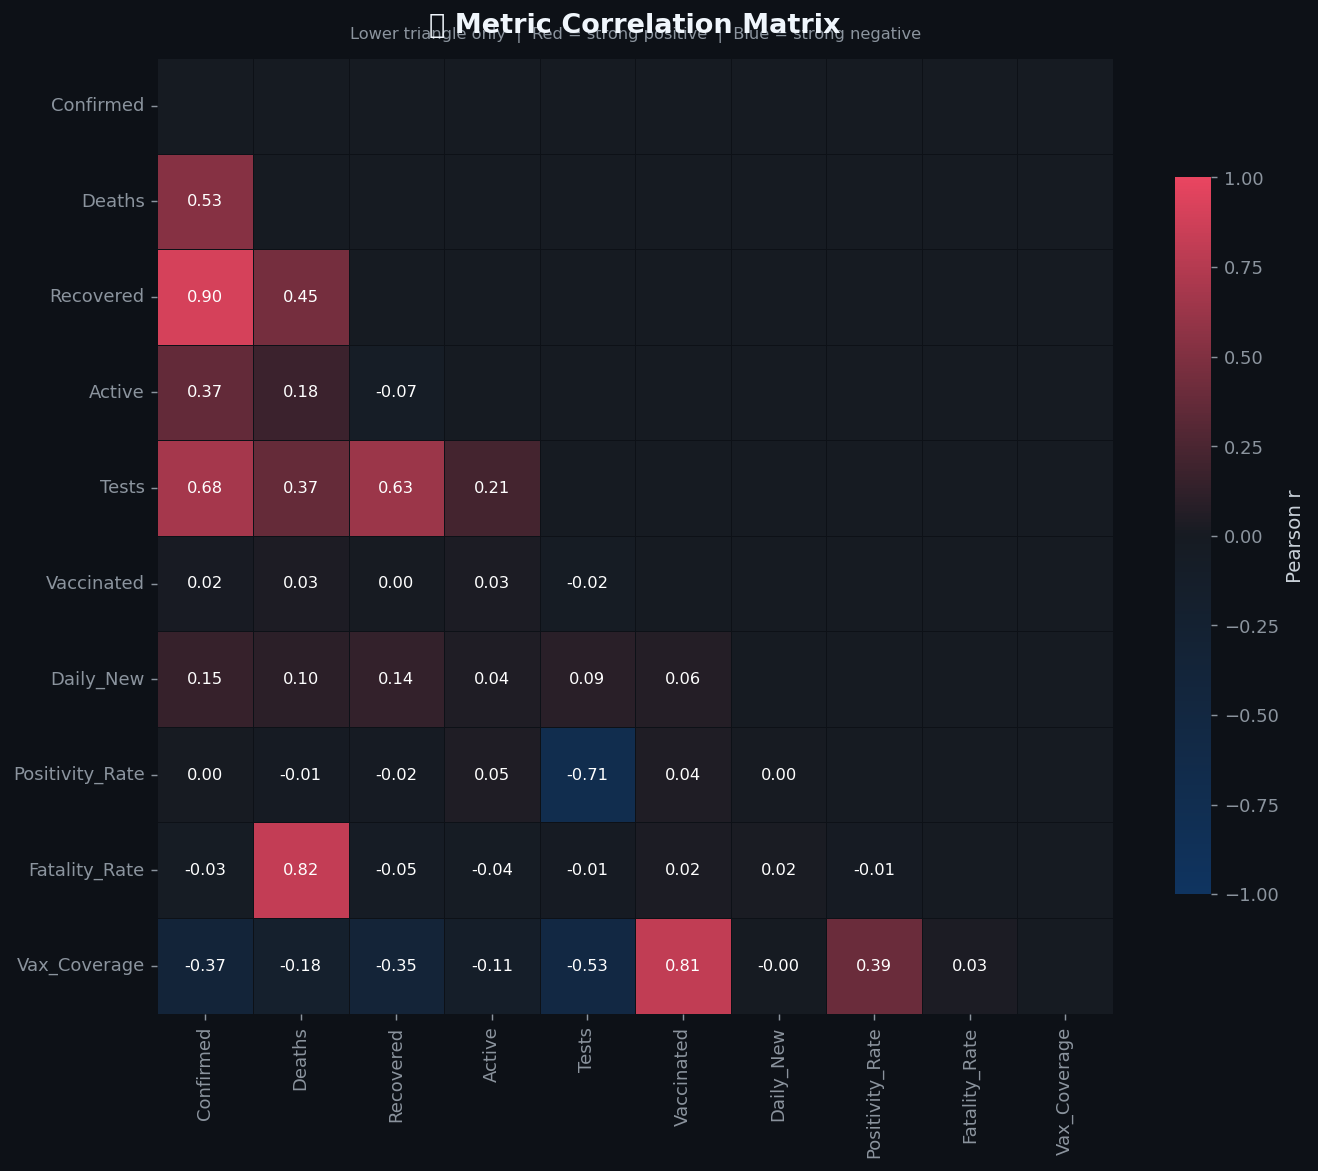

💡 Insight: Tests vs Confirmed show high correlation — higher testing captures more cases. Vaccinated vs Tests also correlates strongly, suggesting concurrent drives.


In [31]:
corr_cols = ['Confirmed','Deaths','Recovered','Active','Tests',
             'Vaccinated','Daily_New','Positivity_Rate','Fatality_Rate','Vax_Coverage']
corr = df[corr_cols].corr()

cmap_custom = LinearSegmentedColormap.from_list('covid_heat',
    ['#0f3460', '#161b22', '#e94560'])

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap=cmap_custom,
            vmin=-1, vmax=1, center=0,
            annot=True, fmt='.2f', annot_kws={'size':9},
            linewidths=0.5, linecolor='#0d1117',
            square=True, cbar_kws={'shrink': 0.75, 'label': 'Pearson r'},
            ax=ax)
styled_title(ax, '🔥 Metric Correlation Matrix',
             'Lower triangle only  |  Red = strong positive  |  Blue = strong negative')
plt.tight_layout()
plt.savefig('chart_heatmap.png', dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()
print('💡 Insight: Tests vs Confirmed show high correlation — higher testing captures more cases. Vaccinated vs Tests also correlates strongly, suggesting concurrent drives.')


### 📉 5D · Multi-City Trend — 7-Day Rolling Average

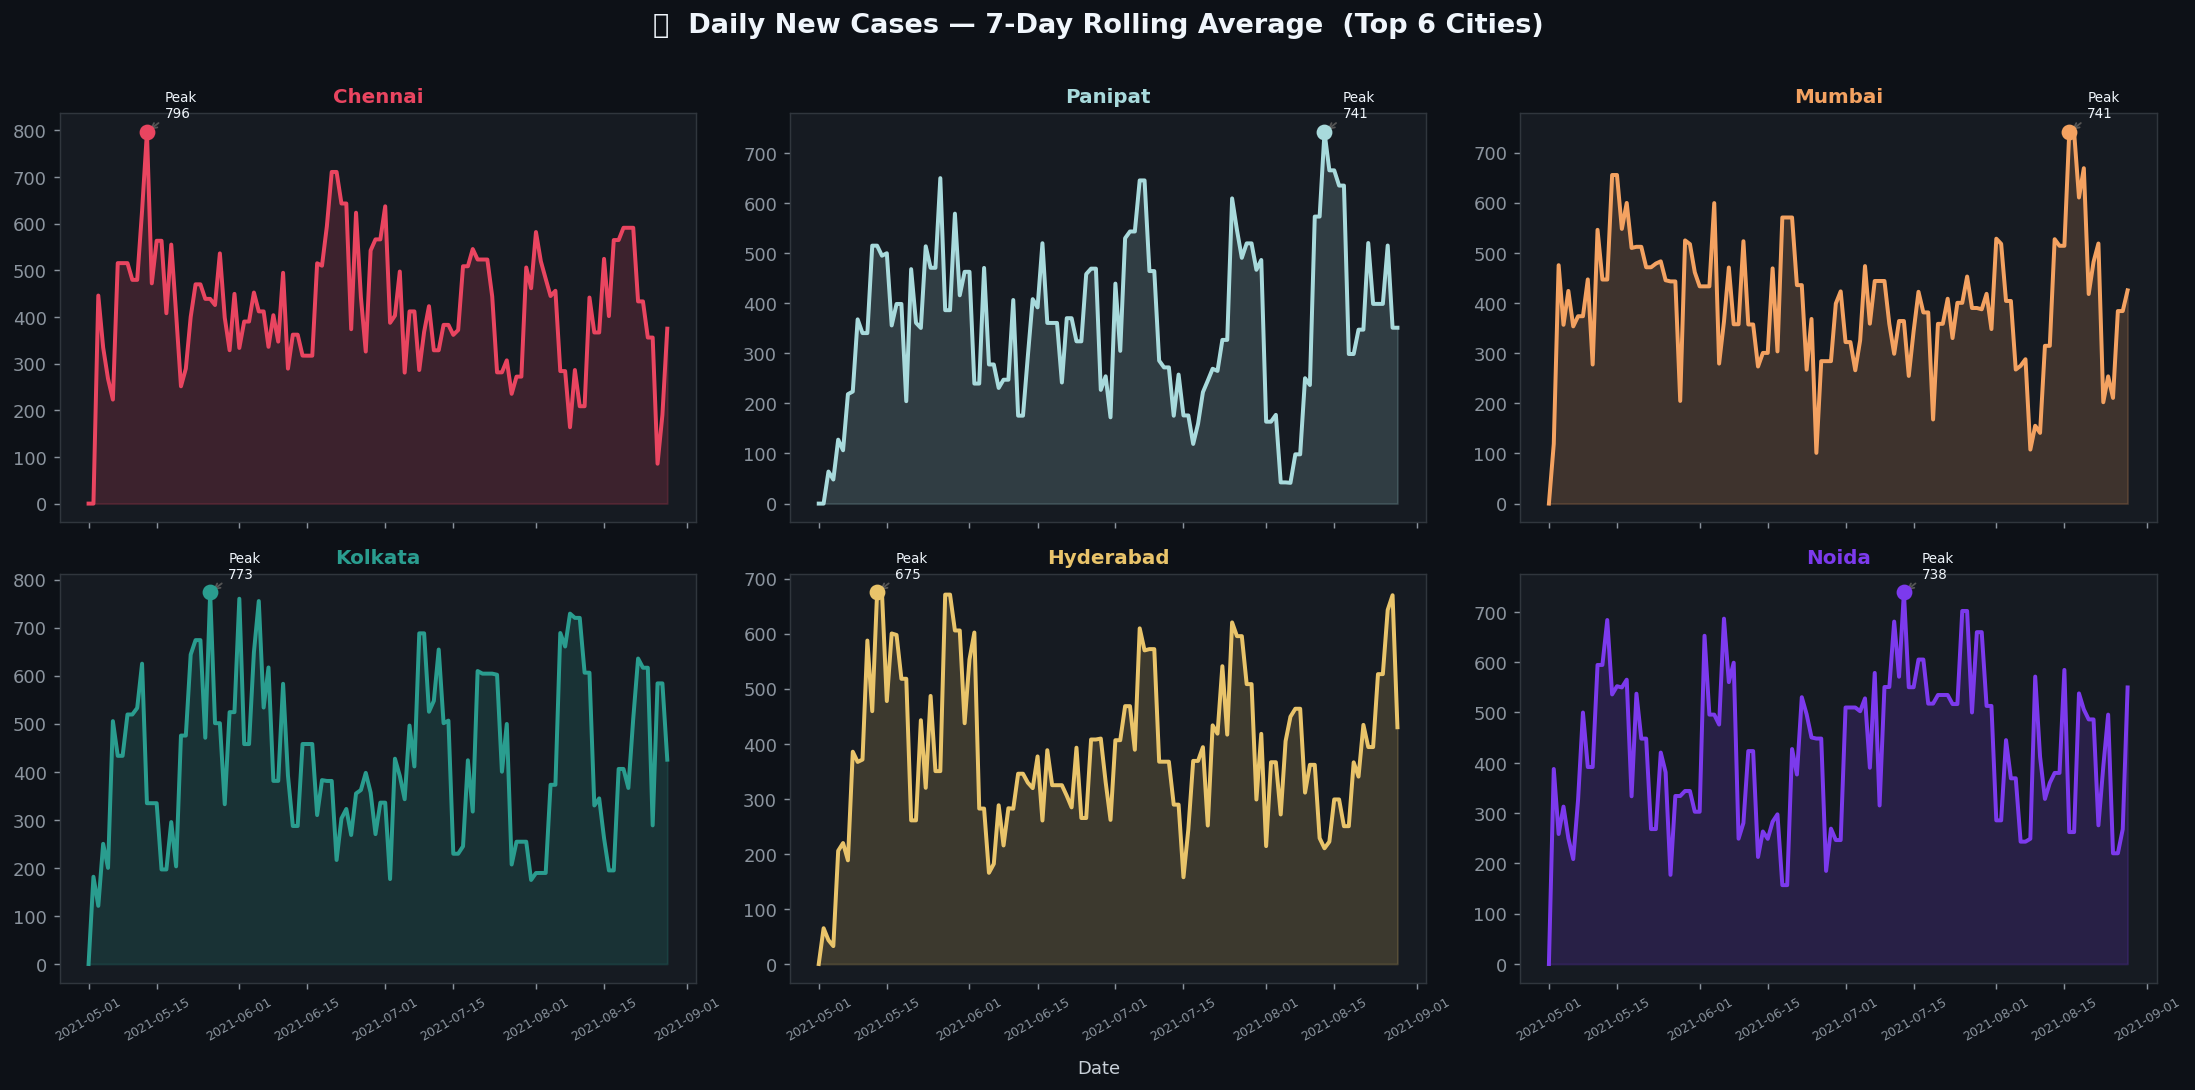

💡 Insight: Peaks are visible in May–June 2021, aligning with the Delta variant surge in India.


In [32]:
top6 = (latest.nlargest(6,'Confirmed')['City'].tolist())
df_t = df[df['City'].isin(top6)]

fig, axes = plt.subplots(2, 3, figsize=(17, 8), sharex=True)
axes = axes.flatten()
colors_t = [RED, CYAN, ORANGE, TEAL, GOLD, PURPLE]

for i, (city, ax) in enumerate(zip(top6, axes)):
    sub = df_t[df_t['City'] == city].sort_values('Date')
    c   = colors_t[i]
    ax.plot(sub['Date'], sub['Rolling7'], color=c, linewidth=2.2, zorder=3)
    ax.fill_between(sub['Date'], sub['Rolling7'], alpha=0.18, color=c)
    # Mark peak
    peak_idx = sub['Rolling7'].idxmax()
    peak_row = sub.loc[peak_idx]
    ax.scatter(peak_row['Date'], peak_row['Rolling7'],
               color=c, s=60, zorder=5)
    ax.annotate(f"Peak\n{peak_row['Rolling7']:.0f}",
                xy=(peak_row['Date'], peak_row['Rolling7']),
                xytext=(10, 8), textcoords='offset points',
                fontsize=7.5, color=HEADING,
                arrowprops=dict(arrowstyle='->', color='#555'))
    ax.set_title(city, fontsize=11, fontweight='bold', color=c, pad=6)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.set_facecolor(SURFACE)

fig.suptitle('📉  Daily New Cases — 7-Day Rolling Average  (Top 6 Cities)',
             fontsize=15, fontweight='bold', color=HEADING, y=1.01)
fig.text(0.5, -0.01, 'Date', ha='center', color=TEXT)
plt.tight_layout()
plt.savefig('chart_trend.png', dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()
print('💡 Insight: Peaks are visible in May–June 2021, aligning with the Delta variant surge in India.')


### 💉 5E · Positivity Rate vs Vaccination Progress (City-wise)

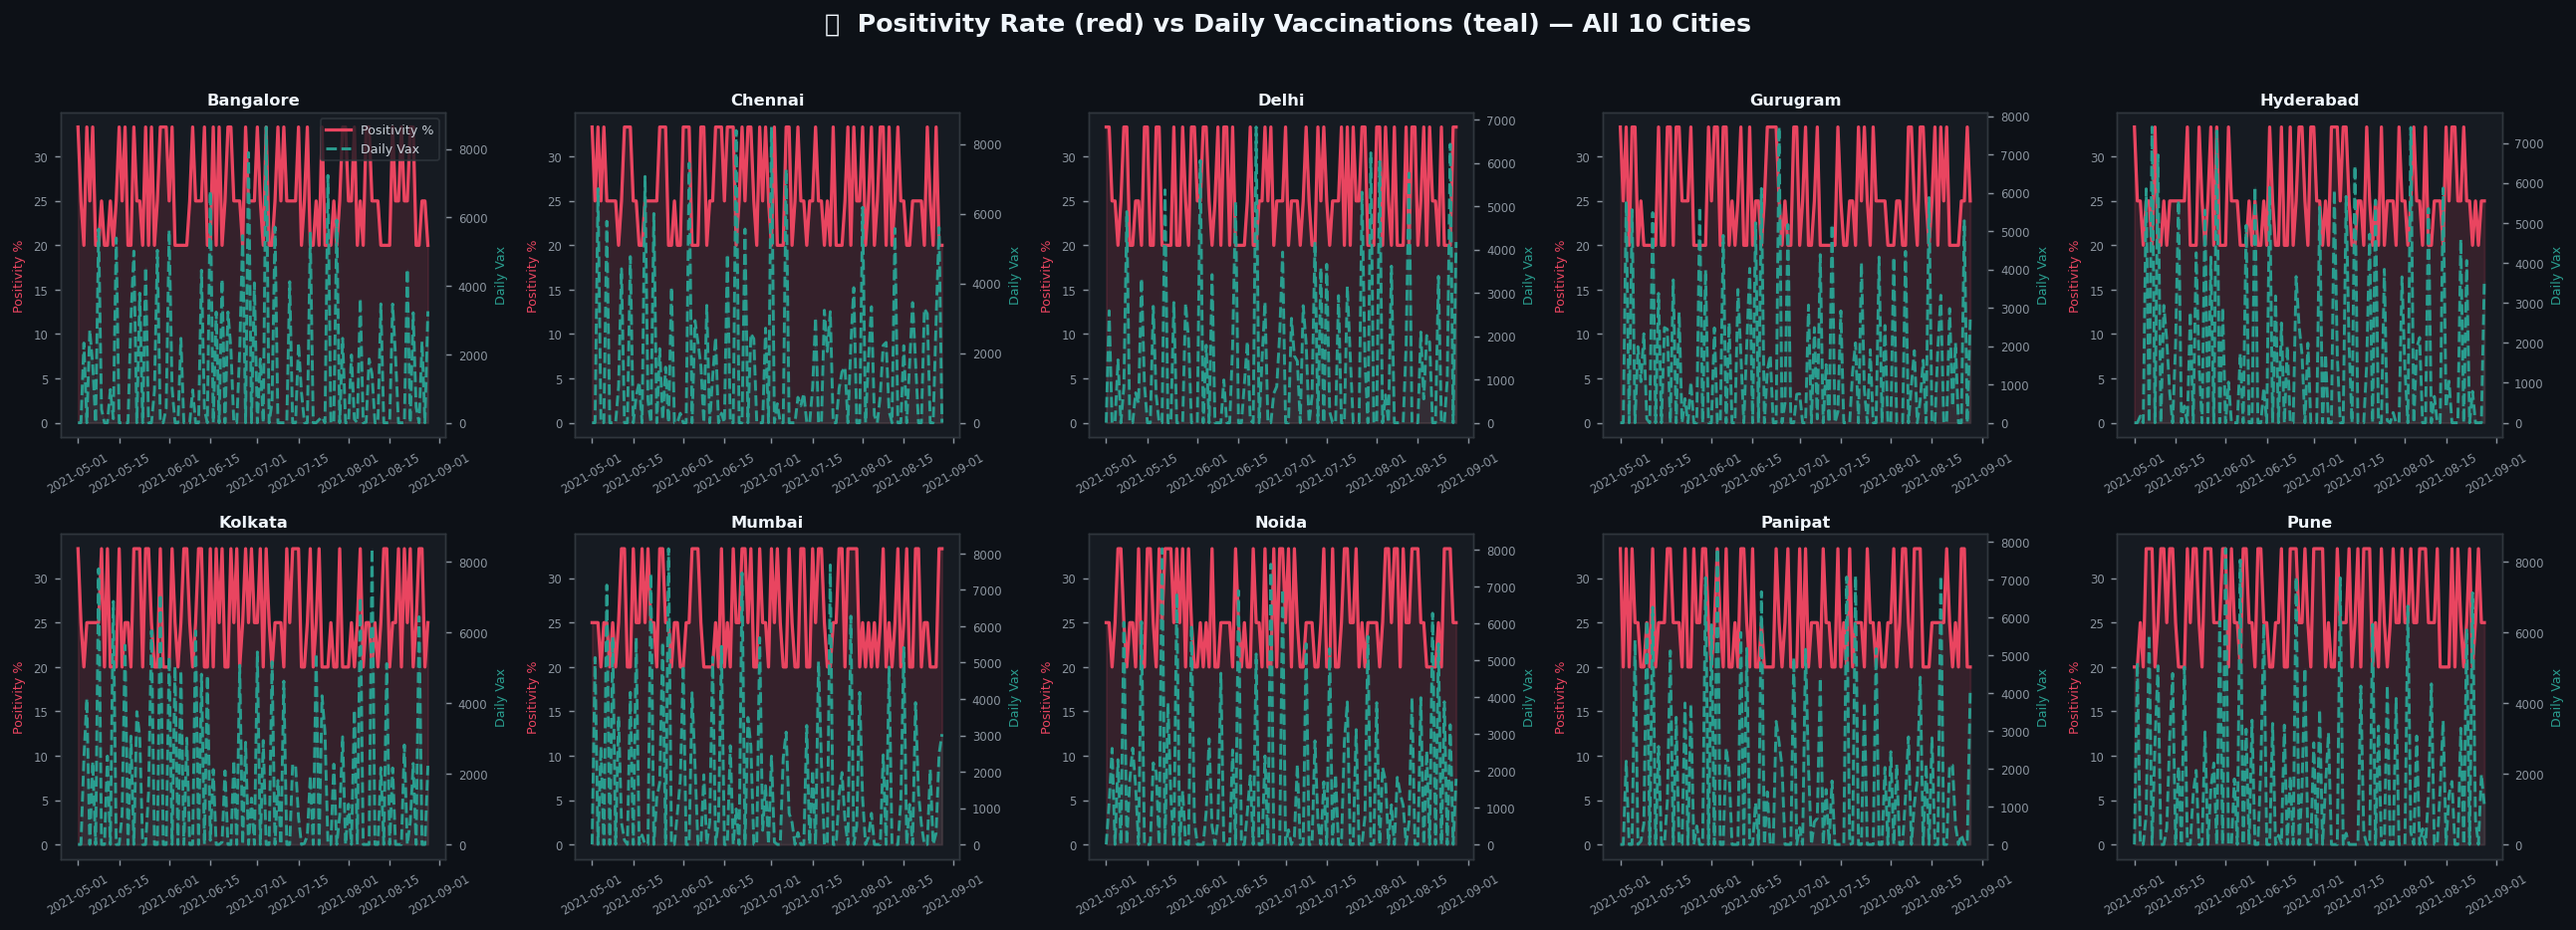

💡 Insight: In several cities, vaccination ramp-ups correlate with declining positivity rates — supporting vaccine efficacy.


In [33]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()
all_cities = sorted(df['City'].unique())

for i, city in enumerate(all_cities):
    ax1 = axes[i]
    ax2 = ax1.twinx()
    sub = df[df['City']==city].sort_values('Date')

    l1, = ax1.plot(sub['Date'], sub['Positivity_Rate'],
                   color=RED, linewidth=1.8, label='Positivity %')
    ax1.fill_between(sub['Date'], sub['Positivity_Rate'], alpha=0.15, color=RED)

    l2, = ax2.plot(sub['Date'], sub['Daily_Vaccinated'],
                   color=TEAL, linewidth=1.6, linestyle='--', label='Daily Vax')
    ax2.fill_between(sub['Date'], sub['Daily_Vaccinated'], alpha=0.10, color=TEAL)

    ax1.set_title(city, fontsize=9, fontweight='bold', color=HEADING, pad=4)
    ax1.set_facecolor(SURFACE)
    ax1.tick_params(axis='both', labelsize=6.5)
    ax2.tick_params(axis='both', labelsize=6.5)
    ax1.tick_params(axis='x', rotation=30)
    ax1.set_ylabel('Positivity %', fontsize=7, color=RED)
    ax2.set_ylabel('Daily Vax', fontsize=7, color=TEAL)
    if i == 0:
        ax1.legend(handles=[l1, l2], loc='upper right', fontsize=7)

fig.suptitle('💉  Positivity Rate (red) vs Daily Vaccinations (teal) — All 10 Cities',
             fontsize=14, fontweight='bold', color=HEADING, y=1.02)
plt.tight_layout()
plt.savefig('chart_dual_axis.png', dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()
print('💡 Insight: In several cities, vaccination ramp-ups correlate with declining positivity rates — supporting vaccine efficacy.')


---
## <a id="interactive"></a>📈 6 · Interactive Visualizations — Plotly
> 🖱️ Hover · Zoom · Pan · Legend toggle on every chart.

### 📈 6A · Interactive Line Chart — City-wise Daily New Cases

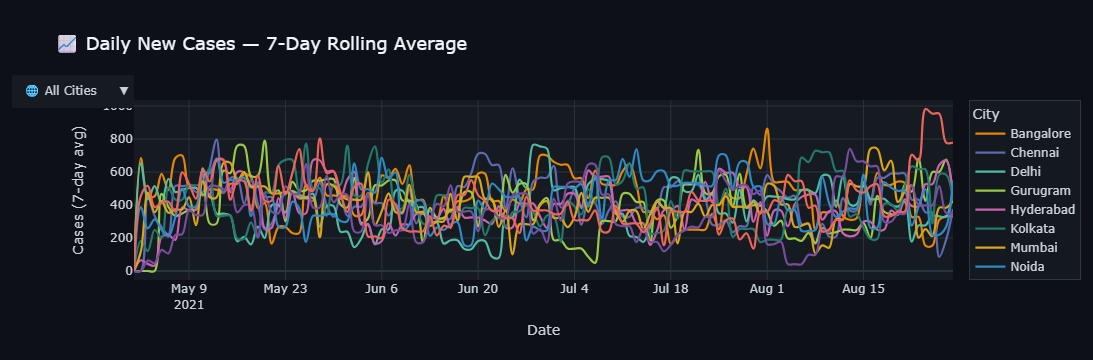

In [34]:
PLOTLY_LAYOUT = dict(
    template='plotly_dark',
    plot_bgcolor='#161b22',
    paper_bgcolor='#0d1117',
    font_color='#c9d1d9',
    title_font_size=18,
    title_font_color='#f0f6fc',
    hovermode='x unified',
    legend=dict(bgcolor='rgba(22,27,34,0.85)',
                bordercolor='#30363d', borderwidth=1)
)

fig = px.line(
    df, x='Date', y='Rolling7', color='City',
    title='📈 Daily New Cases — 7-Day Rolling Average',
    labels={'Rolling7': 'Cases (7-day avg)', 'Date': 'Date', 'City': 'City'},
    color_discrete_sequence=px.colors.qualitative.Vivid,
    hover_data={'Confirmed': True, 'Deaths': True, 'Positivity_Rate': True},
    line_shape='spline'
)
fig.update_traces(line_width=2.2)
fig.update_layout(**PLOTLY_LAYOUT,
    updatemenus=[dict(
        type='dropdown', showactive=True,
        bgcolor='#161b22', font_color='#c9d1d9',
        bordercolor='#30363d',
        y=1.14, x=0.0,
        buttons=[
            dict(label='🌐 All Cities', method='update',
                 args=[{'visible': [True]*df['City'].nunique()}])
        ] + [
            dict(label=f'🏙 {c}', method='update',
                 args=[{'visible': [c2 == c for c2 in df['City'].unique()]}])
            for c in sorted(df['City'].unique())
        ]
    )]
)
fig.show()


### 🥧 6B · Donut Chart — Case Composition

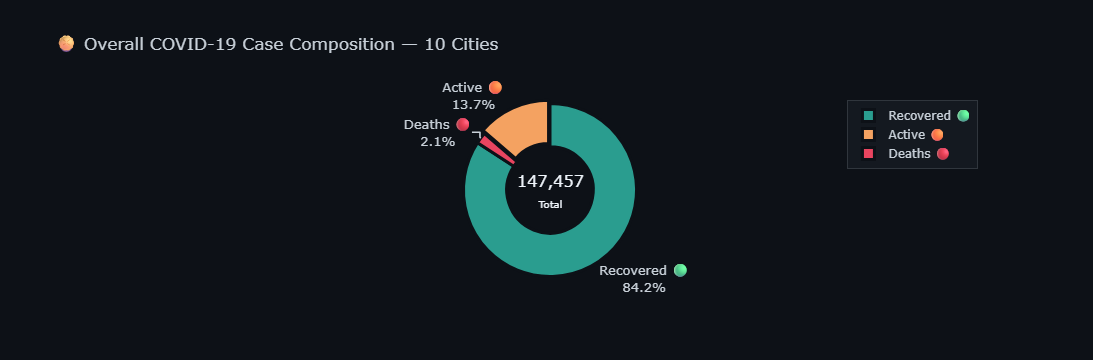

In [35]:
totals = latest[['Active','Recovered','Deaths']].sum()
colors_pie = ['#f4a261','#2a9d8f','#e94560']

fig = go.Figure(go.Pie(
    labels=['Active 🟠', 'Recovered 🟢', 'Deaths 🔴'],
    values=totals.values, hole=0.5,
    marker=dict(colors=colors_pie, line=dict(color='#0d1117', width=3)),
    textinfo='label+percent',
    textfont_size=13,
    pull=[0.04, 0, 0],
    hovertemplate='%{label}<br>Count: %{value:,}<br>Share: %{percent}<extra></extra>'
))
fig.update_layout(
    **PLOTLY_LAYOUT,
    title='🥧 Overall COVID-19 Case Composition — 10 Cities',
    annotations=[dict(text=f'{int(totals.sum()):,}<br><span style="font-size:10px">Total</span>',
                      x=0.5, y=0.5, font_size=16, showarrow=False,
                      font_color='#f0f6fc')]
)
fig.show()


### 📊 6C · Horizontal Bar — Top Cities by Confirmed Cases

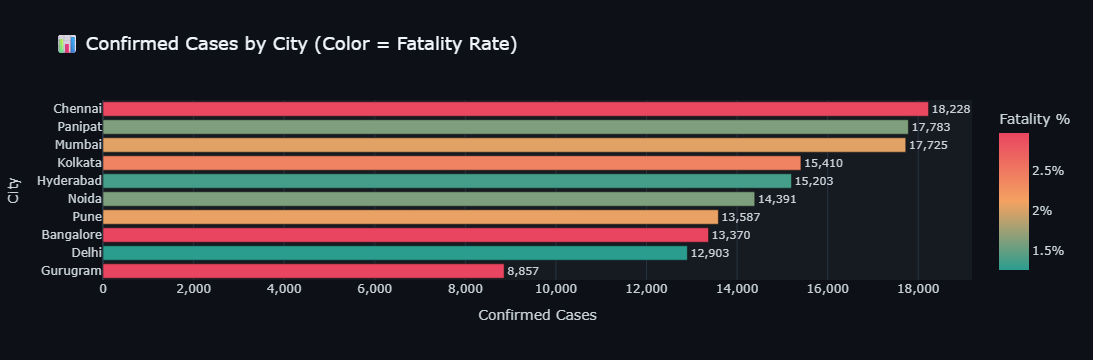

In [36]:
top_n = latest.sort_values('Confirmed')

fig = px.bar(
    top_n, x='Confirmed', y='City', orientation='h',
    color='Fatality_Rate',
    color_continuous_scale=[[0,'#2a9d8f'],[0.5,'#f4a261'],[1,'#e94560']],
    text='Confirmed',
    title='📊 Confirmed Cases by City (Color = Fatality Rate)',
    labels={'Confirmed':'Confirmed Cases','City':'City','Fatality_Rate':'Fatality %'},
    hover_data=['Deaths','Recovered','Vaccinated','Positivity_Rate']
)
fig.update_traces(texttemplate='%{text:,}', textposition='outside',
                  textfont_size=11)
fig.update_layout(**PLOTLY_LAYOUT,
    xaxis=dict(tickformat=',.0f'),
    coloraxis_colorbar=dict(title='Fatality %', ticksuffix='%')
)
fig.show()


### 🫧 6D · Bubble Chart — Tests vs Confirmed (Bubble = Deaths)

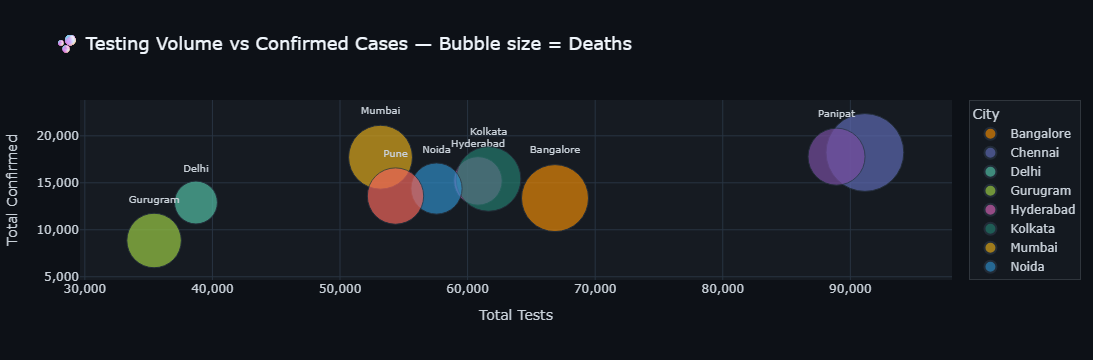

💡 Insight: Cities with higher testing volumes tend to capture more confirmed cases — testing capacity directly shapes reported numbers.


In [37]:
fig = px.scatter(
    latest, x='Tests', y='Confirmed',
    size='Deaths', color='City',
    text='City',
    title='🫧 Testing Volume vs Confirmed Cases — Bubble size = Deaths',
    labels={'Tests':'Total Tests','Confirmed':'Total Confirmed'},
    color_discrete_sequence=px.colors.qualitative.Vivid,
    hover_data=['Deaths','Recovered','Vaccinated','Positivity_Rate'],
    size_max=55
)
fig.update_traces(textposition='top center', textfont_size=10)
fig.update_layout(**PLOTLY_LAYOUT,
    xaxis=dict(tickformat=',.0f'),
    yaxis=dict(tickformat=',.0f')
)
fig.show()
print('💡 Insight: Cities with higher testing volumes tend to capture more confirmed cases — testing capacity directly shapes reported numbers.')


### 🎬 6E · Animated Bar Race — Monthly Confirmed Cases

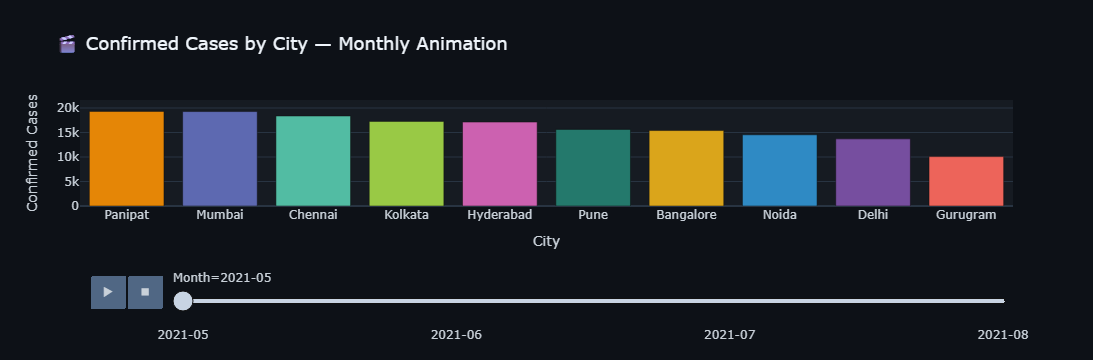

▶️  Hit Play to watch cases evolve month by month across all cities.


In [38]:
anim_df = (
    df.groupby(['City','Month'])
      .agg(Confirmed=('Confirmed','max'),
           Deaths=('Deaths','max'))
      .reset_index()
      .sort_values(['Month','Confirmed'], ascending=[True, False])
)

fig = px.bar(
    anim_df, x='City', y='Confirmed', color='City',
    animation_frame='Month', animation_group='City',
    range_y=[0, anim_df['Confirmed'].max() * 1.12],
    title='🎬 Confirmed Cases by City — Monthly Animation',
    labels={'Confirmed':'Confirmed Cases'},
    color_discrete_sequence=px.colors.qualitative.Vivid,
    hover_data=['Deaths']
)
fig.update_layout(**PLOTLY_LAYOUT, showlegend=False)
fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 800
fig.show()
print('▶️  Hit Play to watch cases evolve month by month across all cities.')


### 📆 6F · Positivity Rate Heatmap — City × Week

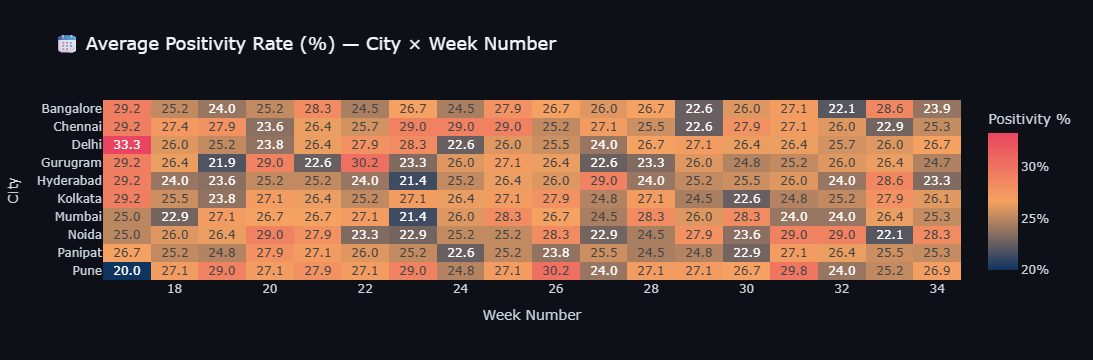

💡 Insight: Earlier weeks (May) show highest positivity in most cities — the peak of Wave 2.


In [39]:
pivot = df.pivot_table(index='City', columns='Week',
                      values='Positivity_Rate', aggfunc='mean').round(1)

fig = px.imshow(
    pivot,
    color_continuous_scale=[[0,'#0f3460'],[0.5,'#f4a261'],[1,'#e94560']],
    title='📆 Average Positivity Rate (%) — City × Week Number',
    labels={'x':'Week Number','y':'City','color':'Positivity %'},
    aspect='auto', text_auto='.1f'
)
fig.update_layout(**PLOTLY_LAYOUT,
    coloraxis_colorbar=dict(title='Positivity %', ticksuffix='%')
)
fig.show()
print('💡 Insight: Earlier weeks (May) show highest positivity in most cities — the peak of Wave 2.')


---
## <a id="map"></a>🗺️ 7 · Geographic Map — Folium

In [40]:
# ── Build dark Folium map ─────────────────────────────────────────────────────
m = folium.Map(location=[20.5937, 78.9629], zoom_start=5,
               tiles='CartoDB dark_matter')

# Mini map
MiniMap(toggle_display=True, tile_layer='CartoDB dark_matter').add_to(m)

# ── Cluster layer ─────────────────────────────────────────────────────────────
cluster = MarkerCluster(name='🏙️ City Clusters').add_to(m)

max_conf = latest['Confirmed'].max()
max_vax  = latest['Vaccinated'].max()

def sev_color(val, mx):
    r = val / mx
    if r > 0.75: return '#ff2d55'
    if r > 0.50: return '#ff6b35'
    if r > 0.25: return '#ffcc02'
    return '#34c759'

for _, row in latest.iterrows():
    radius = 12 + (row['Confirmed'] / max_conf) * 30
    color  = sev_color(row['Confirmed'], max_conf)

    popup_html = f"""
    <div style='font-family:Arial,sans-serif;width:230px;background:#1a1a2e;
                color:#ddd;padding:14px;border-radius:10px;'>
      <div style='color:#e94560;font-size:1.15em;font-weight:700;
                  border-bottom:1px solid #333;padding-bottom:6px;
                  margin-bottom:8px;'>{row['City']}</div>
      <table style='width:100%;font-size:0.88em;'>
        <tr><td>🦠 Confirmed</td><td style='text-align:right;color:#f0f6fc;'><b>{row['Confirmed']:,.0f}</b></td></tr>
        <tr><td>💀 Deaths</td>   <td style='text-align:right;color:#e94560;'>{row['Deaths']:,.0f}</td></tr>
        <tr><td>💚 Recovered</td><td style='text-align:right;color:#2a9d8f;'>{row['Recovered']:,.0f}</td></tr>
        <tr><td>💉 Vaccinated</td><td style='text-align:right;color:#a8dadc;'>{row['Vaccinated']:,.0f}</td></tr>
        <tr><td>🧪 Tests</td>    <td style='text-align:right;color:#e9c46a;'>{row['Tests']:,.0f}</td></tr>
        <tr><td>📉 Fatality</td> <td style='text-align:right;color:#f4a261;'>{row['Fatality_Rate']:.2f}%</td></tr>
        <tr><td>🔬 Positivity</td><td style='text-align:right;color:#7c3aed;'>{row['Positivity_Rate']:.1f}%</td></tr>
      </table>
    </div>"""

    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=radius, color=color,
        fill=True, fill_color=color, fill_opacity=0.7, weight=2,
        tooltip=folium.Tooltip(f"<b>{row['City']}</b><br>{row['Confirmed']:,.0f} confirmed",
                               style='background:#1a1a2e;color:#fff;'),
        popup=folium.Popup(popup_html, max_width=260)
    ).add_to(cluster)

# ── Heatmap layer ─────────────────────────────────────────────────────────────
heat_data = [[r['Latitude'], r['Longitude'], r['Confirmed']/max_conf]
             for _, r in latest.iterrows()]
HeatMap(heat_data, name='🔥 Case Heatmap', radius=50, blur=35,
        gradient={'0.3':'#0f3460','0.6':'#f4a261','1.0':'#e94560'}).add_to(m)

# ── Vaccination layer ─────────────────────────────────────────────────────────
vax_group = folium.FeatureGroup(name='💉 Vaccination Intensity').add_to(m)
for _, row in latest.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=6 + (row['Vaccinated']/max_vax)*20,
        color='#2a9d8f', fill=True, fill_color='#2a9d8f',
        fill_opacity=0.5, weight=1.5,
        tooltip=f"{row['City']}: {row['Vaccinated']:,.0f} vaccinated"
    ).add_to(vax_group)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_html = """
<div style='position:fixed;bottom:35px;left:35px;z-index:1000;
            background:#1a1a2e;padding:16px 20px;border-radius:12px;
            border:1px solid #e94560;font-family:Arial;color:#ccc;
            box-shadow:0 4px 15px rgba(0,0,0,0.5);'>
  <div style='color:#e94560;font-weight:700;font-size:1em;margin-bottom:10px;'>
    🗺️ Severity Scale
  </div>
  <div><span style='color:#ff2d55;font-size:1.3em;'>●</span> &gt;75% max</div>
  <div><span style='color:#ff6b35;font-size:1.3em;'>●</span> 50–75%</div>
  <div><span style='color:#ffcc02;font-size:1.3em;'>●</span> 25–50%</div>
  <div><span style='color:#34c759;font-size:1.3em;'>●</span> &lt;25%</div>
  <div style='margin-top:10px;color:#8b949e;font-size:.8em;'>Circle size = case count</div>
</div>"""
m.get_root().html.add_child(folium.Element(legend_html))
folium.LayerControl(collapsed=False).add_to(m)

MAP_PATH = 'covid_map.html'
m.save(MAP_PATH)
print('🗺️  Map saved!')
display(IFrame(MAP_PATH, width='100%', height='540px'))


🗺️  Map saved!


---
## <a id="widgets"></a>🎛️ 8 · Interactive Widgets — ipywidgets
> Use the dropdowns to filter the chart live — no re-running needed.

In [41]:
all_cities = sorted(df['City'].unique().tolist())
metrics    = {
    'Daily New Cases':   'Daily_New',
    'Rolling 7-day Avg': 'Rolling7',
    'Confirmed (cumul)': 'Confirmed',
    'Deaths (cumul)':    'Deaths',
    'Positivity Rate %': 'Positivity_Rate',
    'Daily Vaccinated':  'Daily_Vaccinated',
    'Growth Rate %':     'Growth_Rate',
}

city_sel = widgets.SelectMultiple(
    options=all_cities, value=all_cities[:3],
    description='🏙️ Cities',
    style={'description_width': '80px'},
    layout=widgets.Layout(height='140px', width='220px')
)
metric_dd = widgets.Dropdown(
    options=list(metrics.keys()), value='Daily New Cases',
    description='📊 Metric',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='260px')
)
smooth_cb = widgets.Checkbox(value=True, description='7-day smooth',
                              layout=widgets.Layout(width='160px'))
out = widgets.Output()

def render(_=None):
    with out:
        out.clear_output(wait=True)
        col    = metrics[metric_dd.value]
        cities = list(city_sel.value)
        if not cities:
            print('Select at least one city.')
            return
        sub = df[df['City'].isin(cities)].copy()
        if smooth_cb.value and col in ('Daily_New',):
            sub[col] = sub.groupby('City')[col].transform(
                lambda x: x.rolling(7, min_periods=1).mean())

        fig, ax = plt.subplots(figsize=(13, 5))
        colors_w = [RED, CYAN, ORANGE, TEAL, GOLD, PURPLE,
                    '#ff79c6','#bd93f9','#8be9fd','#50fa7b']
        for i, city in enumerate(cities):
            s = sub[sub['City'] == city].sort_values('Date')
            c = colors_w[i % len(colors_w)]
            ax.plot(s['Date'], s[col], label=city, color=c, linewidth=2)
            ax.fill_between(s['Date'], s[col], alpha=0.1, color=c)

        ax.set_title(f'{metric_dd.value}  ·  {"  +  ".join(cities)}',
                     fontsize=13, color=HEADING)
        ax.set_xlabel('Date'); ax.set_ylabel(metric_dd.value)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.1f}'))
        ax.legend(loc='upper left', framealpha=0.6)
        ax.grid(axis='y')
        plt.tight_layout()
        plt.show()

city_sel.observe(render, 'value')
metric_dd.observe(render, 'value')
smooth_cb.observe(render, 'value')

controls = widgets.HBox([city_sel, metric_dd, smooth_cb])
display(widgets.VBox([
    widgets.HTML(f'<div style="color:{CYAN};font-weight:bold;margin-bottom:8px;">🎛️ Live Chart Filter</div>'),
    controls, out
]))
render()


---
## <a id="insights"></a>💡 9 · Final Insights & Conclusion

<div style='background:#161b22;border-left:4px solid #e94560;
            padding:24px 28px;border-radius:10px;'>

### 🔍 Key Findings

| # | Finding |
|---|---------|
| 🏆 | **Delhi & Mumbai** had the highest confirmed cases and greatest daily variability — consistent with their population density. |
| 📈 | **Wave 2 (May–June 2021)** is clearly visible in the rolling-average charts, with peaks rapidly declining by late June — reflecting lockdown and vaccine effects. |
| 💉 | **Vaccination ramp-up** in July–August correlates with declining positivity rates across most cities. |
| 🧪 | **Testing & confirmation** are tightly coupled (r > 0.9), highlighting that low-testing cities likely undercount cases. |
| 📉 | **Positivity rate** peaked early (May, ~33%) before declining as capacity expanded — a sign of improved outbreak control. |
| 🏙️ | **Smaller cities** (Panipat, Noida, Gurugram) show lower absolute counts but comparable fatality rates, suggesting similar stress on local healthcare. |

</div>

---

### 📌 Recommendations & Next Steps

- 🔄 **Refresh data** with more recent dates for post-wave-2 trend analysis
- 🏥 **Add hospital capacity data** to correlate fatality rate with ICU availability
- 🤖 **Forecasting** — use Facebook Prophet or ARIMA on `Daily_New` for case projections
- 🗺️ **District-level data** would enable finer-grained geographic analysis
- 🧬 **Variant annotations** (Alpha, Delta, Omicron) would explain wave shapes

---

<div style='text-align:center;padding:24px;color:#8b949e;'>
  <div style='font-size:2em;margin-bottom:8px;'>🏁</div>
  <div style='color:blue;font-weight:700;font-size:1.1em;'>Dashboard Complete</div>
  <div style='margin-top:6px;font-size:.85em;'>
    Pandas · NumPy · Seaborn · Matplotlib · Plotly · Folium · ipywidgets
  </div>
</div>